In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset, load_from_disk
import mlflow
import mlflow.pytorch
from datetime import datetime
import json

C:\Users\lukb9\Desktop\Dev Projects\inventory-text-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
PATH = '../data'
df = pd.read_excel(f'{PATH}/dataset.xlsx', engine='openpyxl')
df.head()

,id,text,quantity,unit,price,label
0,204884,Am 23.6.2021 neue Automaten montiert und Zulei...,2.50,Stunde,43.5,labor
1,152859,Wc Sitz weiß (1010900),1.00,St,27.0,material
2,201264,Dachkante und Fassade freischneiden Baum Nr. 30,1.00,Stück,80.0,labor
3,157853,Deckenfläche streichen,4.84,m²,4.1,labor
4,253783,SML Übergangsrohn 100 X 50 mm Fabrikat Düker,1.00,ST,20.9,material


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Types:")
print(df.dtypes)
print("\nBasic Statistics:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (229, 6)

Column Types:
id            int64
text         object
quantity    float64
unit         object
price       float64
label        object
dtype: object

Basic Statistics:
                  id    quantity        price
count     229.000000  229.000000   229.000000
mean   195543.519651    8.569271    56.620393
std     37483.252748   63.140112   158.606852
min    133117.000000    0.338000     0.090000
25%    164489.000000    1.000000     6.710000
50%    194983.000000    1.000000    18.640000
75%    231396.000000    2.750000    42.000000
max    256347.000000  934.680000  1892.180000

Missing Values:
id           0
text         0
quantity     0
unit        24
price        0
label        0
dtype: int64



=== Text Statistics by Label ===
          text_length  word_count  count
label                                   
labor      109.225000   12.475000     80
material    80.175182   10.065693    137
other       57.500000    6.916667     12


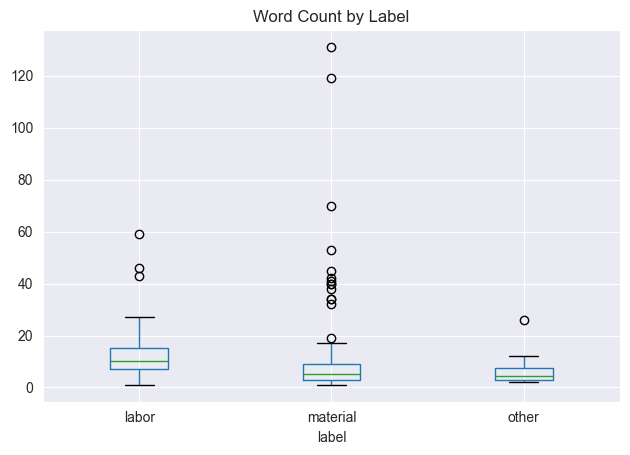

<Axes: >

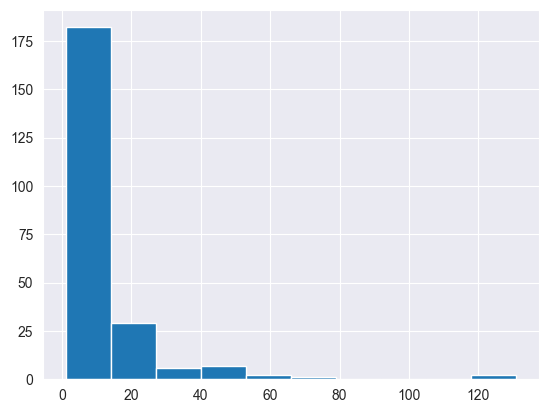

In [4]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print("\n=== Text Statistics by Label ===")
result = df.reset_index().groupby('label').agg({
    'text_length': 'mean',
    'word_count': 'mean'
})
result['count'] = df.groupby('label').size()
print(result)


df.boxplot(column='word_count', by='label')
plt.title('Word Count by Label')
plt.suptitle('')
plt.tight_layout()
plt.show()

df['word_count'].hist()

In [5]:
for i in range(10):
    print(f'row {i}: {df["text"].iloc[i]}')

row 0: Am 23.6.2021 neue Automaten montiert und Zuleitungen aufgeteilt, Montage
row 1: Wc Sitz weiß (1010900)
row 2: Dachkante und Fassade freischneiden Baum Nr. 30
row 3: Deckenfläche streichen
row 4: SML Übergangsrohn 100 X 50 mm Fabrikat Düker
row 5: HT Bogen DN 50 87°
row 6: Viega Optefix 5
row 7: Dispersions-Silikatfarbe
row 8: Kochendwassergeraet Stiebel Eltron EBK 5 GA automatic, 5I, 074287, 2kW/230V
row 9: fischer Sanitärbefestigung WCR 6 X 80, für Stand WC¿S und Bidets


In [6]:
def preprocess_invoice_text(text):
    """
    Minimal preprocessing for German construction/invoice texts
    for DistilBERT fine-tuning

    Fixes only actual data quality issues, keeps informative content
    """
    if pd.isna(text) or text is None:
        return ""

    text = str(text)
    # Remove excessive whitespace (but keep single spaces)
    text = ' '.join(text.split())

    # Fix common OCR/scanning errors if present
    text = text.replace('  ', ' ')  # Double spaces

    return text.strip()

In [7]:
df['clean_text'] = df['text'].apply(preprocess_invoice_text)

In [8]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"Using device: CPU (project configured for CPU-only)")

CUDA available: True
PyTorch version: 2.9.1+cu130
CUDA version (PyTorch): 13.0


In [9]:
# ==================== 1. SETUP ====================
device = torch.device('cpu')
print(f"Using device: {device} (CPU-only)")

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

Using device: cuda


In [10]:
label_map = {
    'labor': 0,
    'material': 1,
    'other': 2
}
inverse_label_map = {v: k for k, v in label_map.items()}

df['label_id'] = df['label'].map(label_map)

print("Label distribution:")
print(df['label'].value_counts())
print(f"\nTotal samples: {len(df)}")

Label distribution:
label
material    137
labor        80
other        12
Name: count, dtype: int64

Total samples: 229


In [11]:
# First split: 80% train+val, 20% test
train_val_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_id']
)

# Second split: 80% train, 20% validation (of the train_val set)
train_df, val_df = train_test_split(
    train_val_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_val_df['label_id']
)

In [12]:
# Handle class imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['label_id']),
    y=train_df['label_id']
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"\nClass weights: {class_weights}")


Class weights: tensor([0.9542, 0.5594, 6.0833], device='cuda:0')


In [13]:
# Convert to HuggingFace Dataset format
train_dataset = Dataset.from_pandas(
    train_df[['clean_text', 'label_id']].rename(columns={'clean_text': 'text', 'label_id': 'label'})
)
val_dataset = Dataset.from_pandas(
    val_df[['clean_text', 'label_id']].rename(columns={'clean_text': 'text', 'label_id': 'label'})
)
test_dataset = Dataset.from_pandas(
    test_df[['clean_text', 'label_id']].rename(columns={'clean_text': 'text', 'label_id': 'label'})
)

In [14]:
try:
    train_dataset.save_to_disk(f'{PATH}/train')
    val_dataset.save_to_disk(f'{PATH}/val')
    test_dataset.save_to_disk(f'{PATH}/test')
    torch.save(class_weights, f'{PATH}/class_weights.pt')
except Exception as e:
    print(e)

Saving the dataset (1/1 shards): 100%|██████████| 46/46 [00:00<00:00, 6217.59 examples/s]


In [15]:
train_dataset = load_from_disk(f'{PATH}/train')
val_dataset = load_from_disk(f'{PATH}/val')
test_dataset = load_from_disk(f'{PATH}/test')
class_weights = torch.load(f'{PATH}/class_weights.pt')

In [16]:
model_name = 'distilbert-base-german-cased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

# Check token lengths to determine max_length
#[bos_token, eos_token, unk_token, sep_token, pad_token, cls_token, mask_token, extra_special_tokens]
def get_token_lengths(texts):
    lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in texts]
    return lengths

train_lengths = get_token_lengths(train_df['clean_text'].tolist())

# text gets padded to the max length we accept
# when using max length we have than all text is padded to 304 even 95% of our tokens <= 95
print(max(train_lengths))
print(int(np.percentile(train_lengths, 95)))
MAX_LENGTH = min(128, int(np.percentile(train_lengths, 95)))
print(f"Using MAX_LENGTH: {MAX_LENGTH}")


def tokenize_function(examples):
    return tokenizer(
        examples['text'],
        padding='max_length',
        truncation=True,
        max_length=MAX_LENGTH
    )

# Tokenize datasets
train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
val_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
print('\n TOKENIZATION DONE')


304
95
Using MAX_LENGTH: 95

 TOKENIZATION DONE


In [17]:
num_labels = len(label_map)
model = DistilBertForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels
)
model.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-german-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(31102, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [18]:
from torch.nn import CrossEntropyLoss

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        loss_fct = CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

In [19]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

In [20]:
output_dir = './results'
model_save_dir = './models/distilbert_invoice_classifier'

training_args = TrainingArguments(
    output_dir=output_dir,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model='f1_weighted',
    greater_is_better=True,
    save_total_limit=2,
    seed=SEED,
    fp16=False,  # CPU-only: mixed precision disabled
    report_to="none",  # We'll use MLflow instead
)

In [21]:
mlflow.set_experiment("distilbert_invoice_classification")

# Start MLflow run
with mlflow.start_run(run_name=f"distilbert_{datetime.now().strftime('%Y%m%d_%H%M%S')}"):

    # Log parameters
    mlflow.log_params({
        "model_name": model_name,
        "max_length": MAX_LENGTH,
        "num_labels": num_labels,
        "train_size": len(train_df),
        "val_size": len(val_df),
        "test_size": len(test_df),
        "seed": SEED,
        "epochs": training_args.num_train_epochs,
        "batch_size": training_args.per_device_train_batch_size,
        "learning_rate": training_args.learning_rate,
        "weight_decay": training_args.weight_decay,
        "warmup_steps": training_args.warmup_steps,
    })

    # Log class distribution
    mlflow.log_dict(
        df['label'].value_counts().to_dict(),
        "class_distribution.json"
    )

    # Log label mapping
    mlflow.log_dict(label_map, "label_mapping.json")

    # Log class weights
    mlflow.log_dict(
        {f"weight_class_{i}": float(w) for i, w in enumerate(class_weights)},
        "class_weights.json"
    )


2026/01/20 17:00:47 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/01/20 17:00:47 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/01/20 17:00:47 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/01/20 17:00:47 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/01/20 17:00:47 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/01/20 17:00:47 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/01/20 17:00:47 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/01/20 17:00:47 INFO mlflow.store.db.utils: Updating database tables
2026/01/20 17:00:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/20 17:00:47 INFO alembic.runtime.migration: Will assume non-transactional DDL.
2026/01/20 17:00:47 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/01/20 17:00:47 INFO alembic.runtime

In [22]:

trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        class_weights=class_weights,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
    )

print("\n" + "="*50)
print("Starting training...")
print("="*50 + "\n")

train_result = trainer.train()

# Log training metrics
mlflow.log_metrics({
    "train_loss": train_result.training_loss,
    "train_runtime": train_result.metrics['train_runtime'],
    "train_samples_per_second": train_result.metrics['train_samples_per_second'],
})

C:\Users\lukb9\AppData\Local\Temp\ipykernel_23268\1616327742.py:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `WeightedTrainer.__init__`. Use `processing_class` instead.
  super().__init__(*args, **kwargs)



Starting training...



Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.056300,1.074408,0.378378,0.238095,0.303089
2,1.076600,1.064837,0.405405,0.270833,0.361486
3,1.043100,1.045640,0.621622,0.425000,0.606081
4,1.011200,1.016522,0.729730,0.495671,0.710425
5,0.968900,0.974295,0.810811,0.550355,0.787119


In [23]:
print("\n" + "="*50)
print("Evaluating on validation set...")
print("="*50 + "\n")

val_results = trainer.evaluate(val_dataset)
print("\nValidation Results:")
for key, value in val_results.items():
    print(f"  {key}: {value:.4f}")
    mlflow.log_metric(f"val_{key}", value)


Evaluating on validation set...




Validation Results:
  eval_loss: 0.9743
  eval_accuracy: 0.8108
  eval_f1_macro: 0.5504
  eval_f1_weighted: 0.7871
  eval_runtime: 0.0619
  eval_samples_per_second: 598.2190
  eval_steps_per_second: 48.5040
  epoch: 5.0000


In [24]:
print("\n" + "="*50)
print("Evaluating on test set...")
print("="*50 + "\n")

test_results = trainer.evaluate(test_dataset)
print("\nTest Results:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")
    mlflow.log_metric(f"test_{key}", value)

# Get predictions for detailed metrics
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

# Classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=[inverse_label_map[i] for i in range(num_labels)],
    digits=4
)
print("\nClassification Report:")
print(report)

# Save report
with open('classification_report.txt', 'w') as f:
    f.write(report)
mlflow.log_artifact('classification_report.txt')

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[inverse_label_map[i] for i in range(num_labels)],
    yticklabels=[inverse_label_map[i] for i in range(num_labels)]
)
plt.title('Confusion Matrix - Test Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
mlflow.log_artifact('confusion_matrix.png')
plt.close()

print("\nConfusion Matrix:")
print(cm)


Evaluating on test set...


Test Results:
  eval_loss: 0.9559
  eval_accuracy: 0.7609
  eval_f1_macro: 0.4974
  eval_f1_weighted: 0.7343
  eval_runtime: 0.2053
  eval_samples_per_second: 224.0210
  eval_steps_per_second: 14.6100
  epoch: 5.0000

Classification Report:
              precision    recall  f1-score   support

       labor     0.8182    0.5625    0.6667        16
    material     0.7429    0.9286    0.8254        28
       other     0.0000    0.0000    0.0000         2

    accuracy                         0.7609        46
   macro avg     0.5203    0.4970    0.4974        46
weighted avg     0.7368    0.7609    0.7343        46


Confusion Matrix:
[[ 9  7  0]
 [ 2 26  0]
 [ 0  2  0]]


C:\Users\lukb9\Desktop\Dev Projects\inventory-text-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lukb9\Desktop\Dev Projects\inventory-text-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lukb9\Desktop\Dev Projects\inventory-text-classification\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

In [25]:
print("\n" + "="*50)
print("Saving model...")
print("="*50 + "\n")

# Save the best model
trainer.save_model(model_save_dir)
tokenizer.save_pretrained(model_save_dir)

# Save configuration
config = {
    "model_name": model_name,
    "max_length": MAX_LENGTH,
    "label_map": label_map,
    "num_labels": num_labels,
    "test_accuracy": float(test_results['eval_accuracy']),
    "test_f1_weighted": float(test_results['eval_f1_weighted']),
    "timestamp": datetime.now().isoformat()
}

with open(f'{model_save_dir}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Log model to MLflow
mlflow.pytorch.log_model(model, "model")
mlflow.log_artifacts(model_save_dir, "saved_model")

print(f"\n✅ Model saved to: {model_save_dir}")
print(f"✅ MLflow run ID: {mlflow.active_run().info.run_id}")
print("\n" + "="*50)
print("Training complete!")
print("="*50)


Saving model...



2026/01/20 17:01:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


PicklingError: Cannot pickle a prepared model with automatic mixed precision, please unwrap the model with `Accelerator.unwrap_model(model)` before pickling it.